## Research a New Strategy

In [4]:
from utils import *
from QRT_utils import *
from strategies import *
from local_data.data import *
from local_data.constants import *

### Load Raw Data

In [ ]:
historical_bb = pd.read_parquet(os.path.join(PRICE_DIR, BB_HISTORICAL))
active_lseg = pd.read_parquet(os.path.join(PRICE_DIR, LSEG_ACTIVE))

### Active Constituents Data

In [ ]:
active_prices_rua, active_vol_rua = get_timeseries(active_lseg, market='.SPX'), get_timeseries(active_lseg, value='Volume', market='.SPX')
active_eligible_rua = eligible_to_trade(active_prices_rua, active_vol_rua, market='.SPX')

active_prices_stoxx, active_vol_stoxx = get_timeseries(active_lseg, market='.STOXX50E'), get_timeseries(active_lseg, value='Volume', market='.STOXX50E')
active_eligible_stoxx = eligible_to_trade(active_prices_stoxx, active_vol_stoxx, market='.STOXX50E')

### Historical Constituents Data

In [ ]:
hist_prices_rua, hist_vol_rua = get_timeseries(historical_bb, market='.SPX', data_type='historical'), get_timeseries(historical_bb, value='Volume', market='.SPX', data_type='historical')
hist_eligible_rua = eligible_to_trade(hist_prices_rua, hist_vol_rua, market='.SPX')

hist_prices_stoxx, hist_vol_stoxx = get_timeseries(historical_bb, market='.STOXX50E', data_type='historical'), get_timeseries(historical_bb, value='Volume', market='.STOXX50E', data_type='historical')
hist_eligible_stoxx = eligible_to_trade(hist_prices_stoxx, hist_vol_stoxx, market='.STOXX50E')

### 1. Write strategy

In [ ]:
def strategy(price_data: pd.DataFrame, vol_eligible: pd.DataFrame, portfolio_start: str) -> tuple[pd.Series, dict]:
    return

weights_rua, stats_rua = strategy(
    price_data=active_prices_rua, 
    vol_eligible=active_eligible_rua, 
    portfolio_start=str(active_prices_rua.index[-1].date())
)
weights_stoxx, stats_stoxx = strategy(
    price_data=active_prices_rua, 
    vol_eligible=active_eligible_rua, 
    portfolio_start=str(active_prices_rua.index[-1].date())
)

pd.concat([pd.Series(stats_rua, name='RUA'), pd.Series(stats_stoxx, name='STOXX')], axis=1)

### 2. Backtest with historical data

In [ ]:
daily_returns, summary = backtest(
    strategy_fn=titman_min_var_momentum,
    price_data=hist_prices_rua, 
    vol_eligible=hist_eligible_rua,
    start_date='2025-03-20',
    end_date='2026-03-20',
    rebalance_freq=5,
    save_csv=True,
    plot=True
)
summary

### 3. Combine RUA & Stoxx porfolios, and scale risk to 500k USD

In [ ]:
from utils import scale_portfolio

scaled_rua, scaled_stoxx = scale_portfolio(
    weights_rua=weights_rua,
    weights_stoxx=weights_stoxx,
    target_risk_usd=500_000,
    display_stats=True
)

### 4. Plot Recent Performance & Submit Positions to QRT

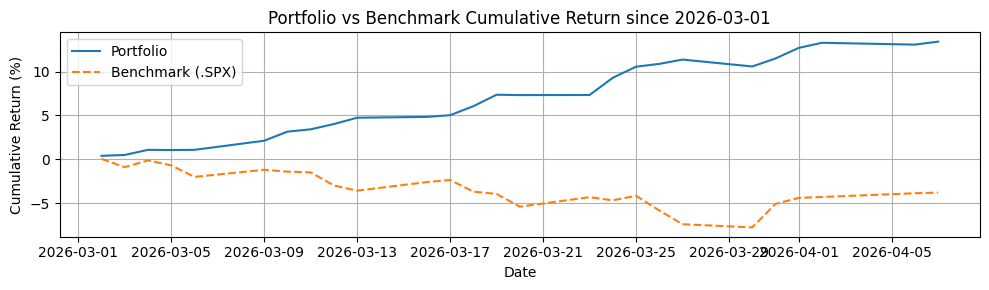

In [ ]:
for pos, reg in [(scaled_rua, 'AMER'), (scaled_stoxx, 'EMEA')]:
    send_new_portfolio(positions=pos, region=reg, validate_only=True)

positions = most_recent_positions(region='AMER')
plot_portfolio_returns(positions, benchmark='.SPX', start_date='2026-03-01', figsize=(10,3))

## Instrunctions

### Hedging
To hedge excessive residual beta in your equity portfolio:
1.	Compute the beta of each stock using a 250-day covariance with its benchmark:
$$\text{Beta} = 0.2 + 0.8 \times \frac{\text{Cov}_{250d}(\text{stock}, \text{benchmark})}{\text{Var}_{250d}(\text{benchmark})}$$
2. Hedge the beta exposure by taking a position in the benchmark equal to:
$$\text{Hedge Position} = -\text{Beta}$$
3. Benchmarks:
  - AMER: S&P 500 (SPX)
  - EMEA: Eurostoxx50

This means that if a stock has a beta of 1.2, you would short 1.2 units of the benchmark to neutralize the market exposure.

### Trading Limits
There are some trading limits for single stocks: 
- Max position = 2.5% of the 60 trading days ADV 
- Max traded per day = 2.5% of the 60 trading days ADV 

For single stocks, there is also a max position in term of USD: 
- Max position = 2 M USD 

If the implied trading by targets exceeds the above limits, the position will be kept constant until all limits are not exceeded anymore. 

### Trading Costs
The execution price will be the mid-price at the end of the next minute after we have received your file (without format error) on the ftp. Additional execution costs of 2bps also apply, along with 0.5% (annually) for financing. 

100% of dividends are paid on short positions. 70% of dividends are received on long positions. 

### Ex-Ante Portfolio Risk

Risk Formula
$$
\text{Risk}_t = \sqrt{ x_t^\top \, \Sigma_t \, x_t }
$$

Where:
- $x_t$ = portfolio weights at time $t$
- $\Sigma_t$ = covariance matrix of asset returns  

Computation Steps
1. Select last 60 daily returns.  
2. Compute daily P&L:

$$
\text{PnL}_t = \text{positions}_{t-1} \cdot \text{return}_t
$$

3. Compute standard deviation of P&L.  
4. Annualise: multiply by $\sqrt{252}$.  

Simulation Parameters
- Asset class: Equities  
- Regions: AMER, EMEA  
- Universe: Russell 3000, Stoxx 600  
- Trading hours: Standard per region  
- Execution cost: 2 bps  
- Financing cost: 0.5% GMV  
- Dividend tax: 30%  
- Spread cost: 0  
- Max traded/day: 2.5% ADV  
- Position limit: 2.5% ADV  
- Auto-hedging: TRUE  
- Risk limit: 500k USD (annualised)